# Explaratory Data Analysis for Price Predicting Regression Model
**This notebook originally belonged to @AlvinWjy25 on github**

> **Dataset Source**: PostgreSQL table `public.fct_ebay_listings` (generated via dbt transformation pipeline, run `dbt run` and `dbt test` to get started).  

> **Target Variables**: `price` (Final) and `price_per_volume` (ablation test)

> **Domain**: Light Novel & Manga E-commerce Listings (eBay)
---
## 1. Objective:
- **Data Understanding**: Examine feature distributions, listing condition categories, and volume attributes extracted from listing titles.
- **Risk & Outlier Filtering**: Quantify listing risk scores (`text_risk_score`, `total_risk_score`) to isolate reliable listings from noisy/scam data.
- **Ablation & Experimentation**: Compare regression baselines for predicting listing price vs price-per-volume.
- **Error Diagnosis**: Perform residual analysis on top prediction errors to guide future feature engineering.

[!TIP]: This notebook is designed with Outline, feel free to navigate around with headings!

[!RECOMMENDED]: [Install Data Wrangler Extension on your IDE](https://marketplace.visualstudio.com/items?itemName=ms-toolsai.datawrangler) to get better view of dataframe presentation across the notebook!

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import os
from dotenv import load_dotenv

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)

load_dotenv('../config/.env')  # reuse .env to prevent leak
os.getcwd()

'c:\\Users\\Alvin\\Music\\project_1\\notebook'

---
## 2. Environment Setup & Data Loading
### Notes & Business Logic:
- Loads database credentials from `config/.env`.
- Pulls processed feature marts directly from `fct_ebay_listings`.
- **Validation Check**: Run `dbt test` prior to analysis to guarantee schema integrity.
- [!NOTE]: This mvp model is ran under older `text_risk_score` version as a finalized modelling version 1. NOT `text_risk_score_v2` for classification.
- Read [1.3 Project Setup Guide: eBay Light Novel Price Intelligence Documentation](#https://app.notion.com/p/eBay-Light-Novel-Price-Intelligence-Documentation-2-0-3bf16382ebe58040abeaeed49986dd13?source=copy_link#3bf16382ebe580cc878bc301b9a7228b) to create and configure your DB if this is your first time running the notebook.

In [2]:
# Koneksi ke Postgres, baca langsung dari tabel marts hasil dbt
DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")

engine = create_engine(f"postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}")

#Schema: 'public' fact table from mart
df_raw = pd.read_sql("SELECT * FROM public.fct_ebay_listings", engine)

print(f"Total baris: {len(df_raw)}")
df_raw.head()

Total baris: 2525


,item_id,title,title_length,title_word_count,currency,condition,seller_location,is_boxset,is_special_edition,is_first_print,total_bonus_count,has_signature,has_merch,has_paper_extra,boxset_side_story_edition_included,standalone_side_story_edition,price,price_per_volume,volume_number,volume_number_end,volume_count,text_risk_score,text_risk_score_v2,price_risk_score,total_risk_score,is_ambigous_bulk_pricing,risk_category,volume_confidence
0,v1|115965603147|0,Spy Classroom Volumes 1-3 Light Novel Set New ...,56,10,USD,Brand New,US,True,False,False,0,False,False,False,False,False,40.5,13.5000,1.0,3.0,3.0,0,0,0,0,False,Low Risk,medium
1,v1|116204521440|0,"Spy Classroom, Vol. 7 (light novel): A Glint i...",79,15,USD,Brand New,US,False,False,False,0,False,False,False,False,False,17.2,17.2000,7.0,NaN,1.0,0,0,0,0,False,Low Risk,high
2,v1|116263745717|0,"Gimai Seikatsu, Days with My Step Sister Light...",80,13,USD,Brand New,MY,True,False,False,0,False,False,False,False,False,149.9,18.7375,1.0,8.0,8.0,70,70,0,70,False,High Risk,medium
3,v1|116267961169|0,The Eminence in Shadow 1-6 Novel English New H...,57,10,USD,Brand New,US,False,False,False,0,False,False,False,False,False,108.0,108.0000,NaN,NaN,1.0,0,0,0,0,False,Low Risk,low
4,v1|116268231670|0,"Bofuri: I Don't Want to Get Hurt, so I'll Max ...",79,17,USD,Brand New,US,False,False,False,0,False,False,False,False,False,17.2,17.2000,13.0,NaN,1.0,0,0,0,0,False,Low Risk,medium


In [3]:
df_raw['condition'].value_counts()

condition
Brand New           1340
Good                 390
Very Good            288
Like New             223
New                   94
Used                  71
Acceptable            58
Ungraded              32
Pre-Owned - Good       1
Name: count, dtype: int64

---
## 3. Dataframe Schema

Full description of each column in df_raw & df_price_model:

### **3.1 Target Variable**
| Column Name | Data Type | Description | Modeling Role |
| :--- | :--- | :--- | :--- |
| `price` | `float` | Listing price in USD | Target Variable (Primary) |
| `price_per_volume` | `float` | Calculated price divided by total volume count | Target Variable (Normalized) |
---
### **3.2 Identifiers & Metadata**
| Column Name | Data Type | Description | Modeling Role |
| :--- | :--- | :--- | :--- |
| `item_id` | `string` | Unique listing ID format (`v1\|listing_id\|index`) | Primary Key / Excluded from training |
| `title` | `string` | Raw listing title text from eBay | Metadata / Text Source |
| `seller_location` | `string` | 2-letter ISO country code of seller | Categorical Feature |
| `currency` | `string` | Listing currency (e.g., USD) | Metadata (Filter check) |

      [NOTE]: all of the product price is based on USD currency via eBay API ingestion by default.
---
### **3.3 Volume & Edition Extraction Features**
- These column is generated/extracted from `staging -> marts` in dbt run

| Column Name | Data Type | Description | Modeling Role |
| :--- | :--- | :--- | :--- |
| `volume_number` | `float` | Starting volume number parsed from title | Numerical Feature |
| `volume_number_end` | `float` | Ending volume number parsed for sets/bundles | Numerical Feature |
| `volume_count` | `float` | Total number of books included in the listing | Core Numerical Feature |
| `is_boxset` | `bool` | Flag indicating if title describes a full boxset | Binary Feature |
| `is_special_edition` | `bool` | Flag for limited/collector/special editions | Binary Feature |
| `boxset_side_story_edition_included` | `bool` | Flag if side story/extra content is included in set | Binary Feature |
| `standalone_side_story_edition` | `bool` | Flag for standalone side stories/spin-offs | Binary Feature |
| `title_length` | `int` | Character count of the title | Numerical Feature |
| `title_word_count` | `int` | Total word count of the title | Numerical Feature |
| `condition` | `string` | Item condition (`Brand New`, `Like New`, `Very Good`, `Good`, `New`, `Used`, `Acceptable`, `Ungraded`, `Pre-owned - Good`) | Categorical Feature |
---
### **3.4 Data Quality & Risk Indicators**
- These column is generated/extracted from `staging -> marts` in dbt run

| Column Name | Data Type | Description | Data Cleaning Role |
| :--- | :--- | :--- | :--- |
| `text_risk_score` | `int` | REGEXP based heuristic score flagging dubious text patterns | Data Filtering Threshold |
| `total_risk_score` | `int` | Combined risk score combining text & seller indicators | Data Filtering Threshold |
| `risk_category` | `string` | Risk tier (`Low Risk`, `Medium Risk`, `High Risk`) | Outlier / Scam Filtering |
| `volume_confidence` | `string` | Confidence grade of volume parsing (`high`, `medium`, `low`) | Quality Weighting |

# **A. Gaining Insight about the DataFrame**

In [4]:
df_raw.describe()

,title_length,title_word_count,total_bonus_count,price,price_per_volume,volume_number,volume_number_end,volume_count,text_risk_score,text_risk_score_v2,price_risk_score,total_risk_score
count,2525.000000,2525.000000,2525.000000,2525.000000,2525.000000,2112.000000,784.000000,2525.000000,2525.000000,2525.000000,2525.000000,2525.000000
mean,70.241188,11.739010,0.287921,78.547881,28.205644,4.318182,16.095663,5.642376,14.998020,16.106931,2.560396,17.558416
std,11.941486,2.329359,0.601003,109.978324,62.265922,5.104506,8.517979,8.391296,28.727123,29.468557,6.947335,30.163465
min,15.000000,3.000000,0.000000,2.490000,0.302093,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,64.000000,10.000000,0.000000,13.500000,10.518519,1.000000,11.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,76.000000,12.000000,0.000000,23.410000,14.990000,2.000000,13.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,79.000000,13.000000,0.000000,125.000000,22.290000,6.000000,26.000000,8.000000,0.000000,0.000000,0.000000,15.000000
max,80.000000,19.000000,4.000000,1999.000000,1999.000000,29.000000,45.000000,45.000000,70.000000,70.000000,30.000000,100.000000


## A.1 Inspecting Missing Value

In [5]:
missing_summary = df_raw.isnull().sum().to_frame('missing_count')
missing_summary['missing_%'] = (missing_summary['missing_count'] / len(df_raw) * 100).round(1)
missing_summary.sort_values('missing_count', ascending=False)

,missing_count,missing_%
volume_number_end,1741,69.0
volume_number,413,16.4
condition,28,1.1
item_id,0,0.0
title_word_count,0,0.0
currency,0,0.0
seller_location,0,0.0
is_boxset,0,0.0
is_special_edition,0,0.0
is_first_print,0,0.0


If the listing doesn't have volume_number_end but volume_number exist, it's a single volume listing
- Arround 413 volume failed to be extracted due to missing `Vol.`, `Volumes`, `Part`, `Vol` during REGEXP detection in `staging -> mart` process
- Around 28 listing has empty condition, we will use default fallback of Good [3] since it's sold under secondary market.

In [6]:
df_raw[df_raw['volume_number'].isnull()].head(3)

,item_id,title,title_length,title_word_count,currency,condition,seller_location,is_boxset,is_special_edition,is_first_print,total_bonus_count,has_signature,has_merch,has_paper_extra,boxset_side_story_edition_included,standalone_side_story_edition,price,price_per_volume,volume_number,volume_number_end,volume_count,text_risk_score,text_risk_score_v2,price_risk_score,total_risk_score,is_ambigous_bulk_pricing,risk_category,volume_confidence
3,v1|116267961169|0,The Eminence in Shadow 1-6 Novel English New H...,57,10,USD,Brand New,US,False,False,False,0,False,False,False,False,False,108.00,108.00,NaN,NaN,1.0,0,0,0,0,False,Low Risk,low
7,v1|116798503714|0,Rascal Does Not Dream of Bunny Girl Senpai Ani...,69,11,USD,Brand New,JP,False,False,False,1,True,False,False,False,False,51.81,51.81,NaN,NaN,1.0,70,70,0,70,False,High Risk,low
11,v1|117234412006|0,The Eminence in Shadow Official Anime Art Book,46,8,USD,Very Good,JP,False,False,False,0,False,False,False,False,False,37.99,37.99,NaN,NaN,1.0,0,0,0,0,False,Low Risk,low


Based on the DBT logic:
- if a product have ambigous/non-standard volume number writing in the title, it will be flagged as 'low' in `volume_confidence` column. 
- if a product contain keyword of counterfeit / non-official in title/description, it will be flagged as 'High Risk' in `risk_category` column.

The filtered dataframe from low confidence & high risk category is `df_price_model`:

## A.2 Filtering High Risk and Low Confidence 

for Ambigous Volume Number and Non-official Item

In [7]:
print(f"risk_category distribution (all):{df_raw['risk_category'].value_counts()}")

df_price_model = df_raw[(df_raw['risk_category'] != 'High Risk') & (df_raw['volume_confidence'] != 'low')]
print(f"risk_category distribution (w/0 high risk & > low confidence): {df_price_model['risk_category'].value_counts()}")

risk_category distribution (all):risk_category
Low Risk     1984
High Risk     541
Name: count, dtype: int64
risk_category distribution (w/0 high risk & > low confidence): risk_category
Low Risk    1583
Name: count, dtype: int64


After filtering, our data is reduced from 2525 onto 1583. Unfortunately, its the direct consequence of inconsistent product title writing. 

Forcing a wider REGEXP volume number detection may result in data quality drop such as overestimating or underestimating the volume count which poison our model. 

`[Recommendation]`: Use NLP / LLM assisted volume number extraction in bigger scale

Let's do a sanity check first: 
`the result must be empty, always check if you refactor something`



In [8]:
display(df_price_model[df_price_model['volume_count'].isna()])
display(df_price_model[df_price_model['risk_category'] == 'High Risk'])

,item_id,title,title_length,title_word_count,currency,condition,seller_location,is_boxset,is_special_edition,is_first_print,total_bonus_count,has_signature,has_merch,has_paper_extra,boxset_side_story_edition_included,standalone_side_story_edition,price,price_per_volume,volume_number,volume_number_end,volume_count,text_risk_score,text_risk_score_v2,price_risk_score,total_risk_score,is_ambigous_bulk_pricing,risk_category,volume_confidence


,item_id,title,title_length,title_word_count,currency,condition,seller_location,is_boxset,is_special_edition,is_first_print,total_bonus_count,has_signature,has_merch,has_paper_extra,boxset_side_story_edition_included,standalone_side_story_edition,price,price_per_volume,volume_number,volume_number_end,volume_count,text_risk_score,text_risk_score_v2,price_risk_score,total_risk_score,is_ambigous_bulk_pricing,risk_category,volume_confidence


Now let's check volume listing after filter:

In [9]:
missing_summary = df_price_model.isnull().sum().to_frame('missing_count')
missing_summary['missing_%'] = (missing_summary['missing_count'] / len(df_price_model) * 100).round(1)
missing_summary.sort_values('missing_count', ascending=False)


,missing_count,missing_%
volume_number_end,1269,80.2
item_id,0,0.0
title_length,0,0.0
title,0,0.0
currency,0,0.0
condition,0,0.0
seller_location,0,0.0
is_boxset,0,0.0
is_special_edition,0,0.0
is_first_print,0,0.0


In [10]:
df_price_model['is_boxset'].value_counts()

is_boxset
False    1284
True      299
Name: count, dtype: int64

- Our data contains is dominated by 81.1% individual light novel volume, while the rest 18.9% are boxset marked as `is_boxset = True`

Now let's inspect special edition light novel using filtered df_raw (`df_price_model`):

In [11]:
df_price_model[df_price_model['is_special_edition'] == True].describe()

,title_length,title_word_count,total_bonus_count,price,price_per_volume,volume_number,volume_number_end,volume_count,text_risk_score,text_risk_score_v2,price_risk_score,total_risk_score
count,78.000000,78.000000,78.000000,78.000000,78.000000,78.000000,5.000000,78.000000,78.0,78.0,78.000000,78.000000
mean,75.846154,12.512821,0.948718,121.968846,105.845233,5.730769,21.400000,2.307692,0.0,0.0,0.384615,0.384615
std,6.869993,1.726370,0.681813,136.277886,123.657290,4.679808,6.542171,5.245425,0.0,0.0,2.386274,2.386274
min,53.000000,8.000000,0.000000,8.850000,8.850000,1.000000,12.000000,1.000000,0.0,0.0,0.000000,0.000000
25%,75.000000,12.000000,1.000000,43.505000,31.162500,1.000000,17.000000,1.000000,0.0,0.0,0.000000,0.000000
50%,79.000000,13.000000,1.000000,79.900000,74.910000,5.000000,26.000000,1.000000,0.0,0.0,0.000000,0.000000
75%,80.000000,13.000000,1.000000,188.557500,187.530000,8.000000,26.000000,1.000000,0.0,0.0,0.000000,0.000000
max,80.000000,17.000000,3.000000,999.000000,999.000000,17.000000,26.000000,26.000000,0.0,0.0,15.000000,15.000000


## A.3 Data Figure & Presenting Challenge

### A.3.1 Price Figure w/o special edition listings

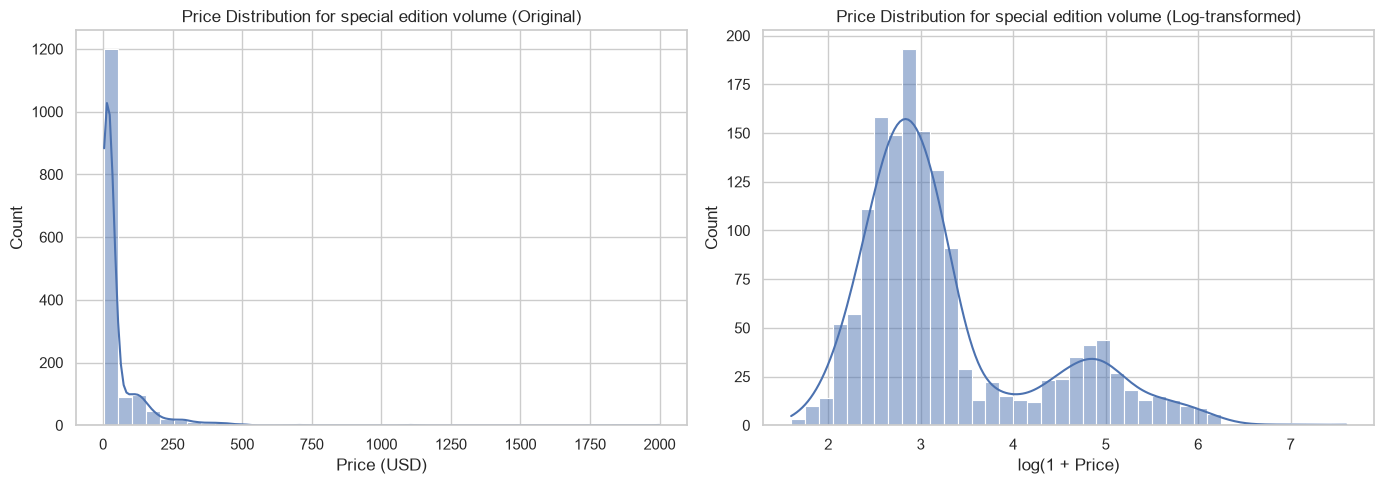

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_price_model.loc[df_price_model["is_special_edition"] == False, "price"], bins = 40, kde = True, ax = axes[0])
axes[0].set_title('Price Distribution for special edition volume (Original)')
axes[0].set_xlabel('Price (USD)')

sns.histplot(np.log1p(df_price_model.loc[df_price_model["is_special_edition"] == False, "price"]), bins = 40, kde = True, ax = axes[1])
axes[1].set_title('Price Distribution for special edition volume (Log-transformed)')
axes[1].set_xlabel('log(1 + Price)')

plt.tight_layout()
plt.show()

### A.3.2 Price Figure for special edition listings

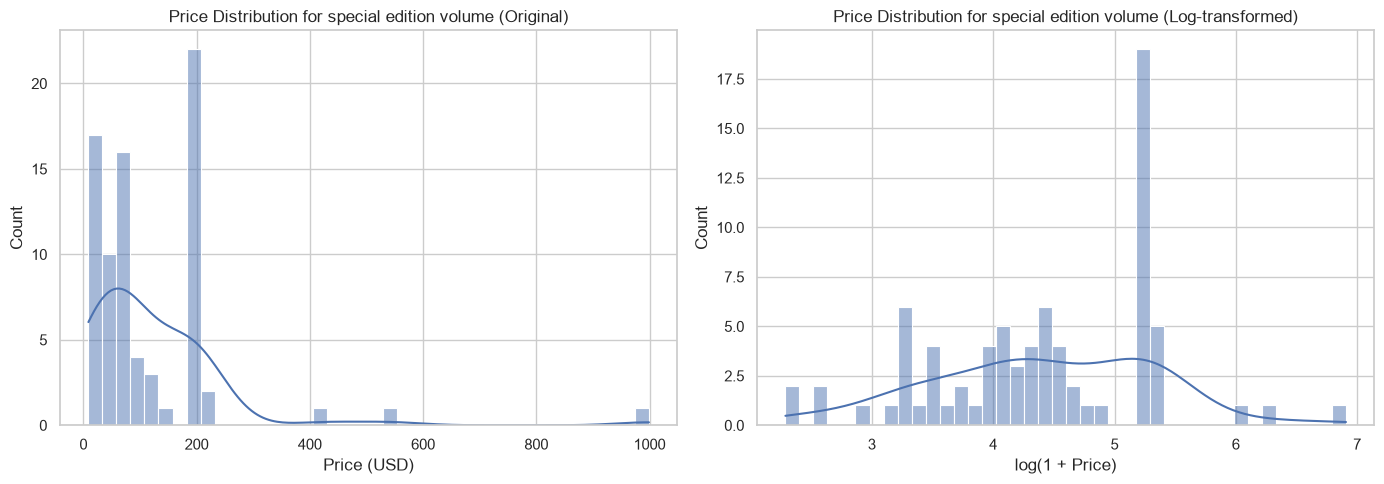

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_price_model.loc[df_price_model["is_special_edition"] == True, "price"], bins = 40, kde = True, ax = axes[0])
axes[0].set_title('Price Distribution for special edition volume (Original)')
axes[0].set_xlabel('Price (USD)')

sns.histplot(np.log1p(df_price_model.loc[df_price_model["is_special_edition"] == True, "price"]), bins = 40, kde = True, ax = axes[1])
axes[1].set_title('Price Distribution for special edition volume (Log-transformed)')
axes[1].set_xlabel('log(1 + Price)')

plt.tight_layout()
plt.show()

### A.3.3 Price for all kind of light novel

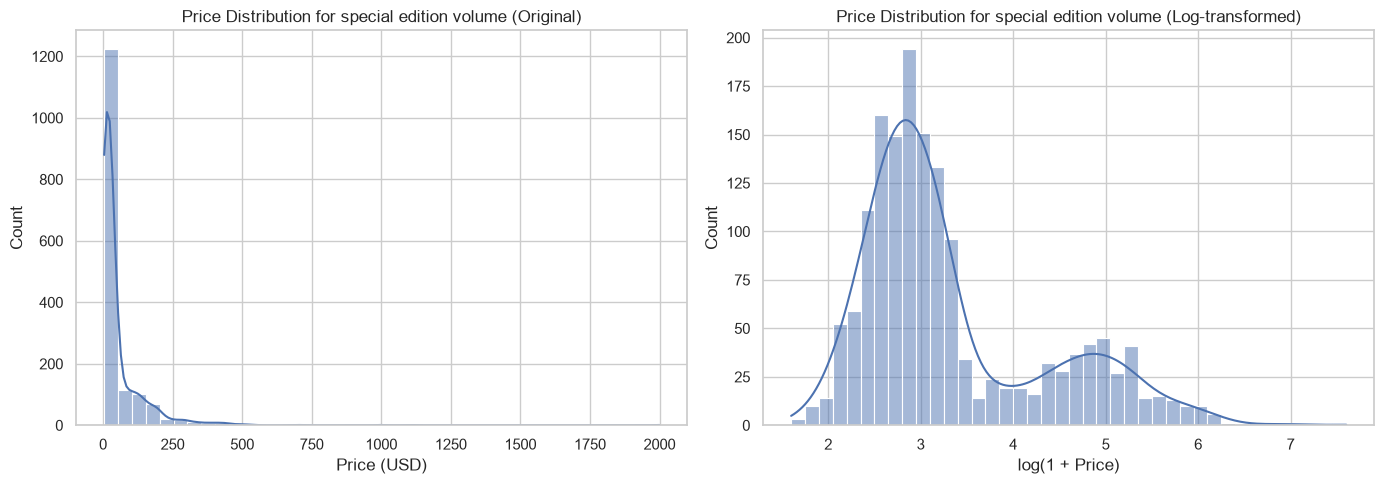

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_price_model["price"], bins = 40, kde = True, ax = axes[0])
axes[0].set_title('Price Distribution for special edition volume (Original)')
axes[0].set_xlabel('Price (USD)')

sns.histplot(np.log1p(df_price_model["price"]), bins = 40, kde = True, ax = axes[1])
axes[1].set_title('Price Distribution for special edition volume (Log-transformed)')
axes[1].set_xlabel('log(1 + Price)')

plt.tight_layout()
plt.show()

Refering to `A.3.2 Price Figure for special edition listings` After filtering, we only have 94 row of data where light novel has either special bonus, short stories, first printing, etc.

These special edition light novel presents many challanges:
1. **Data sparsity & high variance**: with only 94 observations, complex model or heavy gradient boosters without strong regularization will easily overfit to noise or rare outliers.

2. **Extreme Price skewness**: Shown by histogram & summary stats, price ranges from 8.85 to 1.999 dollars, with median of 80 and 75th percentile of 194.31. A single max value of almost 2k dollars creates massive swkewness which will disproportionately pull linear models or MSE-based loss function.

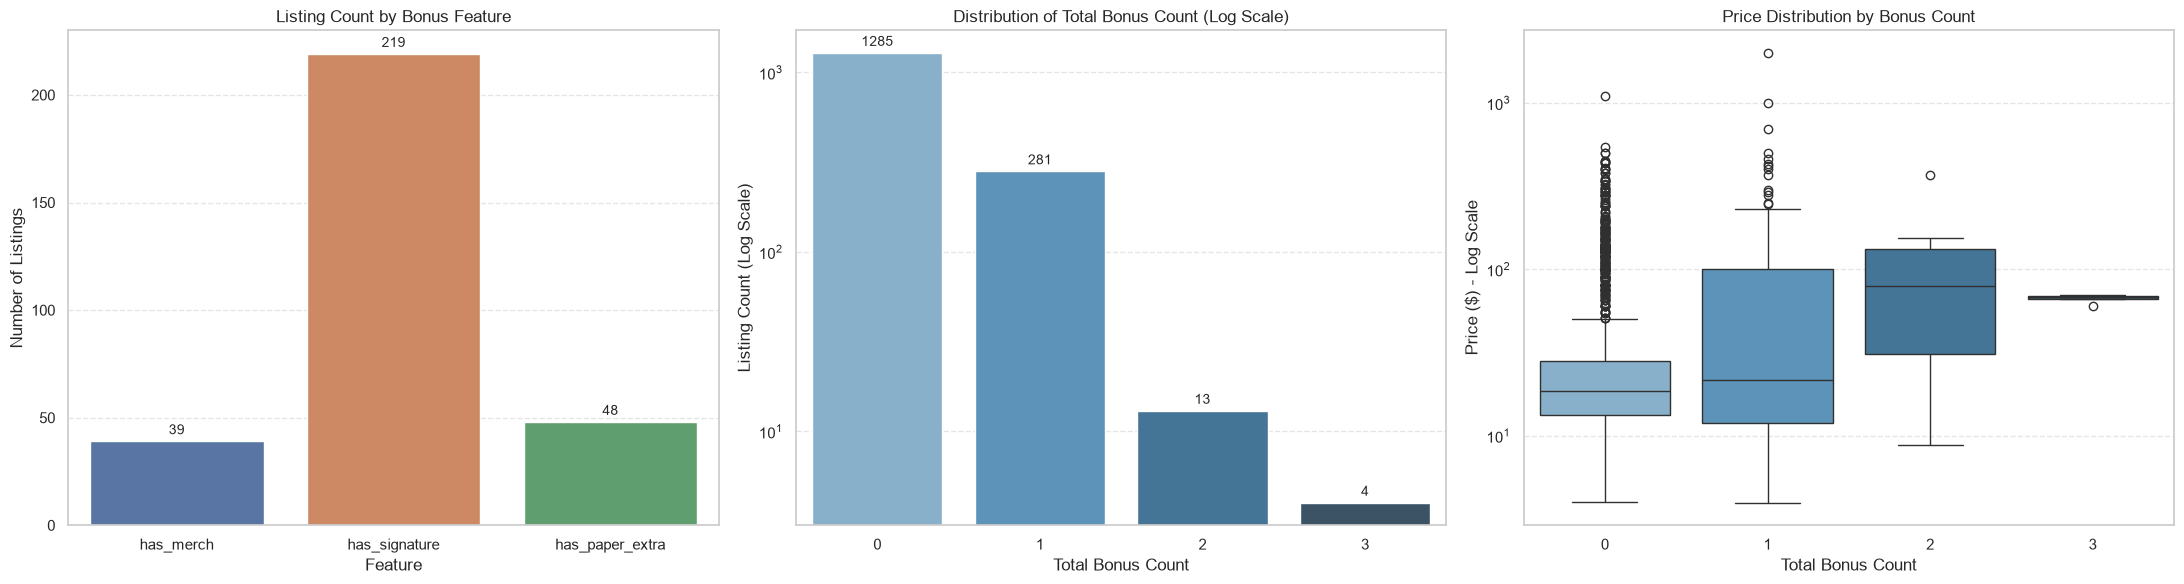

In [15]:
import warnings 
warnings.filterwarnings('ignore')
feature_counts = df_price_model[['has_merch', 'has_signature', 'has_paper_extra']].sum()

# Buat 1x3 grid (axes[2] diisi dengan boxplot harga per total_bonus_count)
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# --- Subplot 1: Feature Counts ---
sns.barplot(
    x=feature_counts.index, 
    y=feature_counts.values, 
    palette=['#4C72B0', '#DD8452', '#55A868'],
    ax=axes[0]
)

axes[0].set_title('Listing Count by Bonus Feature', fontsize=12)
axes[0].set_ylabel('Number of Listings')
axes[0].set_xlabel('Feature')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

for p in axes[0].patches:
    height = int(p.get_height())
    if height > 0:
        axes[0].annotate(
            f'{height}',
            (p.get_x() + p.get_width() / 2., p.get_height()),
            ha='center', va='bottom', fontsize=10, xytext=(0, 3),
            textcoords='offset points'
        )

# --- Subplot 2: Total Bonus Count (Log Scale) ---
sns.countplot(
    data=df_price_model, 
    x='total_bonus_count', 
    palette='Blues_d',
    ax=axes[1]
)
axes[1].set_yscale('log')
axes[1].set_title('Distribution of Total Bonus Count (Log Scale)', fontsize=12)
axes[1].set_xlabel('Total Bonus Count')
axes[1].set_ylabel('Listing Count (Log Scale)')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

for p in axes[1].patches:
    height = int(p.get_height())
    if height > 0:
        axes[1].annotate(
            f'{height}',
            (p.get_x() + p.get_width() / 2., p.get_height()),
            ha='center', va='bottom', fontsize=10, xytext=(0, 3),
            textcoords='offset points'
        )

# --- Subplot 3: Price vs Total Bonus Count ---
sns.boxplot(
    data=df_price_model, 
    x='total_bonus_count', 
    y='price', 
    palette='Blues_d',
    ax=axes[2]
)
axes[2].set_yscale('log')
axes[2].set_title('Price Distribution by Bonus Count', fontsize=12)
axes[2].set_xlabel('Total Bonus Count')
axes[2].set_ylabel('Price ($) - Log Scale')
axes[2].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [16]:
feature_counts

has_merch           39
has_signature      219
has_paper_extra     48
dtype: int64

[!NOTE]: `has_signature` is not considered as special edition.

Chart 1: Listing Count by Bonus Feature:
- `has_signature` dominates as a atribute bonus identified with a total of 213 listing.
- `has_paper_extra` followed behind with extra such as (obi, booklet, drama CD, clear file) identified at 47 listing
- `has merch` is the least containing (tapestry, acrylic standee, figure) with 39 listing available.

Chart 2: Distribution of Total Bonus Count (Log Scale)
- The majorit of light novel listings (1,272 data) doesn't have bonus attribute.
- There are around 274 listing with exactly 1 bonus, 2 bonus at 13 data and 3 bonus at 4 data. 

Chart 3: Observed Price Distribution by Bonus Count
- There is a increase of median price as bonus goes up (monotonic increase):
    - 0 Bonus: Median is arround $18-20
    - 1 Bonus: Median slightly increase but variance range significantly spread, depending of what's the bonus.
    - 2 Bonus: Median significantly increase to around ~$80-$100 dollars
    - 3 Bonus: Baseline price is stable at ~$70 dollars due to scarce light novel product containing 3 bonus at once in listings. 

More data is required to represent the true nature of 2 bonus (12 data) and 3 bonus (4 data) count actual price range.

In [17]:
for col in ['condition', 'seller_location']:
    print(f"{col}: {df_price_model[col].nunique()} unique category")
    print(df_price_model[col].value_counts())
    print()

condition: 7 unique category
condition
Brand New     743
Good          319
Very Good     224
Like New      132
New            82
Acceptable     42
Used           41
Name: count, dtype: int64

seller_location: 7 unique category
seller_location
US    1153
JP     268
MY      71
GB      45
AU      42
CA       3
DE       1
Name: count, dtype: int64



# B. Encoding & Feature Engineering

## B.1 FE: get_volume_tier for grouping large, medium, small volume signal

In [18]:
def get_volume_tier(count):
    if count == 1:
        return 1  # single_volume
    elif 2 <= count <= 5:
        return 2  # small_bundle
    elif 6 <= count <= 15:
        return 3  # medium_set
    else:
        return 4  # complete_large_set

df_price_model['volume_tier'] = df_price_model['volume_count'].apply(get_volume_tier)
df_price_model['volume_tier_encoded'] = df_price_model['volume_count'].apply(get_volume_tier)

location_counts = df_price_model['seller_location'].value_counts()
rare_locations = location_counts[location_counts < 30].index

df_price_model['seller_location_grouped'] = df_price_model['seller_location'].replace(
    rare_locations, 'Other'
)

## B.2 Encode: Condition - Ordinal

In [19]:
condition_map = {
    'Acceptable': 1,
    'Used': 3,
    'Good': 3,
    'Very Good': 4,
    'Like New': 5,
    'New': 6,
    'Brand New': 7,
    'unknown': 3  # Neutral fallback (middle ground)
}

df_price_model['condition_encoded'] = df_price_model['condition'].map(condition_map).fillna(3)

In [20]:
df_price_model = df_price_model.drop(columns = "condition")

Quick Sanity check:

In [21]:
df_price_model[df_price_model['volume_number'].isna()]

,item_id,title,title_length,title_word_count,currency,seller_location,is_boxset,is_special_edition,is_first_print,total_bonus_count,has_signature,has_merch,has_paper_extra,boxset_side_story_edition_included,standalone_side_story_edition,price,price_per_volume,volume_number,volume_number_end,volume_count,text_risk_score,text_risk_score_v2,price_risk_score,total_risk_score,is_ambigous_bulk_pricing,risk_category,volume_confidence,volume_tier,volume_tier_encoded,seller_location_grouped,condition_encoded


# **C. Preparing Pipeline for Modelling**

## C.1 SMAPE Calculation

Why not MAPE? MAPE is often preferred over MAPE because it fixes the division-by-zero problem when actual values are zero, caps extreme percentage spikes, and treats over- and under-forecasting more evenly instead of unfairly penalizing high prediction.

In [22]:
import numpy as np

def calculate_smape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    
    # Avoid division by zero when both y_true and y_pred are 0
    epsilon = 1e-10
    denominator = np.where(denominator == 0, epsilon, denominator)
    
    return np.mean(np.abs(y_pred - y_true) / denominator) * 100

In [23]:
from sklearn.model_selection import train_test_split, RepeatedKFold, GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LogisticRegressionCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
from sklearn.compose import TransformedTargetRegressor
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.utils.class_weight import compute_sample_weight

## C.2 Define Features & Splitting

In [24]:
df_price_model['seller_location_grouped'].value_counts()

seller_location_grouped
US       1153
JP        268
MY         71
GB         45
AU         42
Other       4
Name: count, dtype: int64

In [25]:
numeric_features = [
    'title_length', 
    'title_word_count', 
    'volume_count',
    'volume_tier_encoded',
    'condition_encoded',
    'total_bonus_count'
]

categorical_features = [
    'currency', 
    'seller_location_grouped'
]

boolean_features = [
    'is_boxset', 
    'is_special_edition', 
    # 'is_bonus_added_by_third_party',
    'boxset_side_story_edition_included', 
    'standalone_side_story_edition',
    'is_first_print',
    'has_signature',
    'has_merch',
    'has_paper_extra',
]

def split_train_test(df):
    feature_cols = numeric_features + categorical_features + boolean_features
    target_col = 'price'

    X = df[feature_cols]
    y = df[target_col]

    df_meta = df[['item_id', 'title', 'is_special_edition', 'is_boxset']]

    X_train, X_test, y_train, y_test, indices_train, indices_test = train_test_split(
        X, y, df.index, test_size = 0.2, random_state = 42
    )

    print(f"Train: {len(X_train)}, Test: {len(X_test)}")

    return X, y, df_meta, X_train, X_test, y_train, y_test, indices_train, indices_test

X, y, df_meta, X_train, X_test, y_train, y_test, indices_train, indices_test = split_train_test(df_price_model)

Train: 1266, Test: 317


## C.3 Final Sanity Checks

In [26]:
X.isna().sum().sum()

np.int64(0)

In [27]:
(X_train['volume_count'] < 0).sum()
display(X_train[X_train['volume_count'] < 0].head(5))

,title_length,title_word_count,volume_count,volume_tier_encoded,condition_encoded,total_bonus_count,currency,seller_location_grouped,is_boxset,is_special_edition,boxset_side_story_edition_included,standalone_side_story_edition,is_first_print,has_signature,has_merch,has_paper_extra


In [28]:
X_train.head(5)

,title_length,title_word_count,volume_count,volume_tier_encoded,condition_encoded,total_bonus_count,currency,seller_location_grouped,is_boxset,is_special_edition,boxset_side_story_edition_included,standalone_side_story_edition,is_first_print,has_signature,has_merch,has_paper_extra
1703,50,8,1.0,1,7,0,USD,US,False,False,False,False,False,False,False,False
361,80,14,1.0,1,7,0,USD,US,False,False,False,False,False,False,False,False
1939,50,11,1.0,1,7,0,USD,US,False,False,False,False,False,False,False,False
2159,80,15,1.0,1,7,0,USD,US,False,False,False,False,False,False,False,False
2306,68,12,1.0,1,7,0,USD,GB,False,False,False,False,False,False,False,False


Make sure no negative price are present:

In [29]:
np.sum(df_price_model[df_price_model['price'] < 0])

item_id                                 0
title                                   0
title_length                            0
title_word_count                        0
currency                                0
seller_location                         0
is_boxset                               0
is_special_edition                      0
is_first_print                          0
total_bonus_count                       0
has_signature                           0
has_merch                               0
has_paper_extra                         0
boxset_side_story_edition_included      0
standalone_side_story_edition           0
price                                 0.0
price_per_volume                      0.0
volume_number                         0.0
volume_number_end                     0.0
volume_count                          0.0
text_risk_score                         0
text_risk_score_v2                      0
price_risk_score                        0
total_risk_score                  

Make sure categorical feature is a string

In [30]:
X_train[categorical_features] = X_train[categorical_features].astype(str)
X_test[categorical_features] = X_test[categorical_features].astype(str)

# **D. Creating Modular Pipeline**

In [31]:
preprocessor = ColumnTransformer(
    transformers = [
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output = False), categorical_features),
        ('bool', OneHotEncoder(drop='if_binary', handle_unknown='ignore', sparse_output=False), boolean_features)
    ], remainder = 'passthrough'
)

def change_model(model_reggressor, verbose:int):
    model = TransformedTargetRegressor(
        regressor=model_reggressor,
        func=np.log1p,       
        inverse_func=np.expm1 
    )

    baseline_pipeline = Pipeline(steps = [
        ('preprocessor', preprocessor),
        ('scale', RobustScaler(with_centering=False)), 
        ('regressor', model)
    ])
    
    baseline_pipeline.fit(X_train, y_train)
    y_pred_train = baseline_pipeline.predict(X_train)
    y_pred_test = baseline_pipeline.predict(X_test)

    def get_metrics(y_true, y_pred):
        return {
            'R2': r2_score(y_true, y_pred),
            'MAE': mean_absolute_error(y_true, y_pred),
            'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
            'MAPE': mean_absolute_percentage_error(y_true, y_pred),
            'SMAPE': calculate_smape(y_true, y_pred)
        }

    metrics_train = get_metrics(y_train, y_pred_train)
    metrics_test = get_metrics(y_test, y_pred_test)
    
    comparison = pd.DataFrame({'Train': metrics_train, 'Test': metrics_test})
    comparison['Gap (Train-Test)'] = comparison['Train'] - comparison['Test']
    print(comparison.round(3))

    r2_gap = metrics_train['R2'] - metrics_test['R2']
    if r2_gap > 0.15:
        print(f"\n[!WARN]:\t R2 Wide Gap train-test is detected! = {r2_gap:.3f}")
    else:
        print(f"\n[OK]:\tR2 Gap is acceptable({r2_gap:.3f})")

    results = pd.DataFrame({
        'item_id': df_meta.loc[indices_test, 'item_id'],
        'title': df_meta.loc[indices_test, 'title'],
        'is_boxset': df_meta.loc[indices_test, 'is_boxset'],
        'is_special_edition': df_meta.loc[indices_test, 'is_special_edition'],
        'volume_count': X_test['volume_count'],
        'Actual': y_test.values,
        'Predicted': y_pred_test
    }, index=indices_test)

    results['Residual'] = results['Actual'] - results['Predicted']
    results['Abs_Error'] = np.abs(results['Residual'])
    results['APE (%)'] = (results['Abs_Error'] / results['Actual']) * 100 

    # display 10 biggest error
    import matplotlib.pyplot as plt

    if verbose == 1:
        display(results.sort_values(by='Abs_Error', ascending=False))
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        # Plot 1: Actual vs Predicted
        axes[0].scatter(results['Actual'], results['Predicted'], alpha=0.5, color='blue')
        axes[0].plot([results['Actual'].min(), results['Actual'].max()], 
                    [results['Actual'].min(), results['Actual'].max()], 'r--', lw=2) # Line 45 derajat
        axes[0].set_xlabel('Actual')
        axes[0].set_ylabel('Predicted')
        axes[0].set_title('Actual vs Predicted')

        # Plot 2: Residual Plot
        axes[1].scatter(results['Predicted'], results['Residual'], alpha=0.5, color='purple')
        axes[1].axhline(y=0, color='r', linestyle='--')
        axes[1].set_xlabel('Predicted')
        axes[1].set_ylabel('Residual (Actual - Predicted)')
        axes[1].set_title('Residual Plot')

        plt.tight_layout()
        plt.show()

        # display(X_train.head(5))

    return baseline_pipeline

## **D.1 Ablation Test 1 - w/ Ambigous Price Per Volume & High Variance**

In [32]:
lrr = change_model(LinearRegression(), 0)

        Train    Test  Gap (Train-Test)
R2      0.356   0.527            -0.171
MAE    23.233  21.754             1.479
RMSE   83.196  48.684            34.512
MAPE    0.419   0.411             0.008
SMAPE  34.685  34.366             0.319

[OK]:	R2 Gap is acceptable(-0.171)


In [33]:
rfr = change_model(RandomForestRegressor(random_state = 42, n_jobs = -1 ), 0)

        Train    Test  Gap (Train-Test)
R2      0.736   0.577             0.159
MAE    10.763  18.827            -8.065
RMSE   53.271  46.071             7.201
MAPE    0.179   0.423            -0.244
SMAPE  16.839  30.818           -13.979

[!WARN]:	 R2 Wide Gap train-test is detected! = 0.159


In [34]:
import warnings as warnings
warnings.filterwarnings("ignore")
lgbm = change_model(LGBMRegressor(random_state=42, objective='regression_l1', learning_rate=0.05, force_row_wise = True), 0)

[LightGBM] [Info] Total Bins 121
[LightGBM] [Info] Number of data points in the train set: 1266, number of used features: 16
[LightGBM] [Info] Start training from score 3.008894
        Train    Test  Gap (Train-Test)
R2      0.430   0.589            -0.159
MAE    17.491  18.230            -0.740
RMSE   78.313  45.406            32.907
MAPE    0.287   0.362            -0.075
SMAPE  24.342  29.296            -4.954

[OK]:	R2 Gap is acceptable(-0.159)


        Train    Test  Gap (Train-Test)
R2      0.607  -0.787             1.394
MAE    10.074  22.381           -12.306
RMSE   65.030  94.672           -29.641
MAPE    0.187   0.670            -0.483
SMAPE  18.222  29.339           -11.117

[!WARN]:	 R2 Wide Gap train-test is detected! = 1.394


,item_id,title,is_boxset,is_special_edition,volume_count,Actual,Predicted,Residual,Abs_Error,APE (%)
2140,v1|398091542500|666373137432,Re:Zero Starting Life in Another World Vol.1-4...,True,False,43.0,12.99,1513.438721,-1500.448721,1500.448721,11550.798466
1418,v1|336548044455|0,Rascal Does Not Dream of Bunny Girl Senpai Vol...,False,False,1.0,419.99,50.479137,369.510863,369.510863,87.980872
56,v1|127722168206|428888417043,Konosuba God's Blessing on This Wonderful Worl...,False,False,26.0,248.00,24.920223,223.079777,223.079777,89.951523
861,v1|264758690998|566199342059,NEW LIGHT NOVEL Re: Zero kara Hajimeru Isekai ...,True,False,44.0,99.00,284.044586,-185.044586,185.044586,186.913723
322,v1|166977017979|0,Classroom of the Elite (Light Novel) Vol. 2 [P...,False,False,1.0,185.23,18.069084,167.160916,167.160916,90.245055
...,...,...,...,...,...,...,...,...,...,...
1657,v1|363949152806|0,"Spy Classroom, Vol. 1 (light novel) Format: Pa...",False,False,1.0,13.32,13.319774,0.000226,0.000226,0.001699
1680,v1|364312258417|0,"Spy Classroom, Vol. 2 (light novel) Format: Pa...",False,False,1.0,13.32,13.319774,0.000226,0.000226,0.001699
1490,v1|357466358309|0,Re:Zero-Starting Life in Another World Volume ...,False,False,1.0,28.99,28.990105,-0.000105,0.000105,0.000361
1131,v1|298543963276|0,Ascendance of a Bookworm: Part 5 Volume 1 (Lig...,False,False,1.0,18.02,18.019974,0.000026,0.000026,0.000146


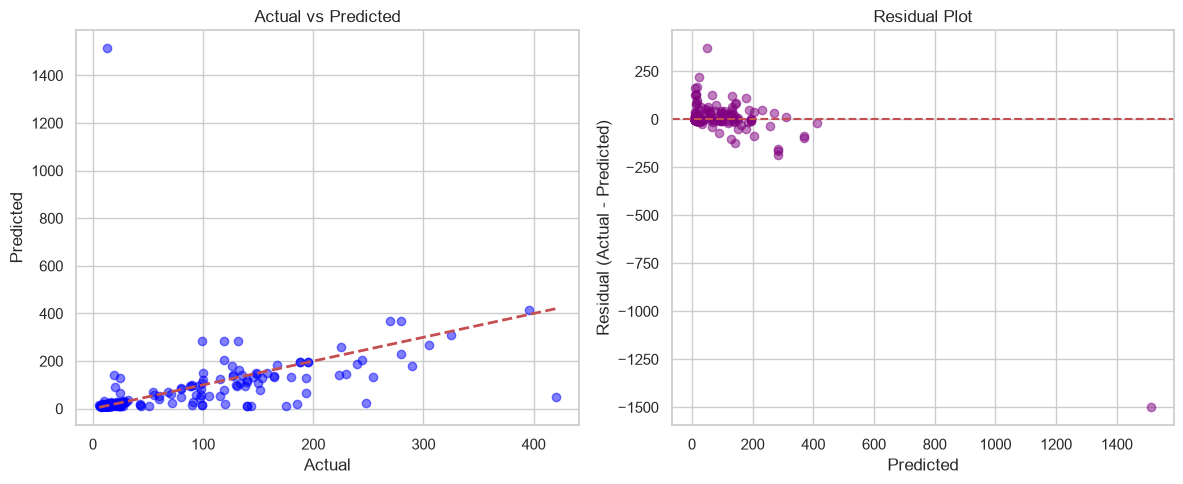

In [35]:
XGBr = change_model(XGBRegressor(random_state=42, tree_method = 'hist', objective='reg:absoluteerror', n_jobs = -1), 1)

Look at the first column that shows the item with the biggest percentage error:

2140	v1|398091542500|666373137432	Re:Zero Starting Life in Another World Vol.1-4...	True	False	43.0	`12.99`	`1120.608521`	-1107.618521	1107.618521

We are looking at 2 problem that cause Absolute Percentage Error that absolutely throw off our XGBr metrics with r^2 of negative value. This happen because there is a fundamental way of how each model handle (out of Distribution/Outlier Sensitivity):
1. Unit price misparsing issue
2. How model handles extreme outlier

---


**1. Unit Price Misparsing Issue:**

A price of $12.99 for 43 Volume is suspiciously too cheap. Searching the product through eBay manually:

![image_1](archive\eBay_Screenshot.png)

[NOTE]: The price may differ due to ingest.py ran in the past when price was 12.99/ea.

It turns out, eBay API was pulling the price as a total even though it's labeled as /ea, not in total. Seller must manually insert pricing type (total / each) in `aspect_unit_of_sale`, but most of it's column are missing or too generic such as 'Comic Book Lot', 'Single', 'Boxset':

Query for Diagnose:
```
select
	aspect_unit_of_sale,
	count(*)
from int_ebay_listing_risk_analysis 
group by aspect_unit_of_sale
```

![image_2](archive\aspect_unit_of_sale.png)

When the data treats 43 volumes of light novel set of $12.99/ea as total price of $12.99, the `price_per_volume` significantly drops to ~#0.30. Identifying suspiciously low price_per_volume regardless of the condition can be a useful way to identify mislabeled price listings, lets do an experiment:

To identify suspiciously low `price_per_volume`, we can do a threhold test and see our model performance

In [36]:
thresholds = [0, 2, 3, 4, 4.2, 4.4, 4.5, 4.6, 4.8, 5, 6, 8, 10, 9999]
results = []

def change_model2(model_reggressor, verbose:int):
    # Pipeline
    model = TransformedTargetRegressor(
        regressor=model_reggressor,
        func=np.log1p,       
        inverse_func=np.expm1 
    )

    baseline_pipeline = Pipeline(steps = [
        ('preprocessor', preprocessor),
        ('scale', RobustScaler(with_centering=False)), 
        ('regressor', model)
    ])
    
    baseline_pipeline.fit(X_train, y_train)
    y_pred = baseline_pipeline.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    smape = calculate_smape(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results = pd.DataFrame({
        'item_id': df_meta.loc[indices_test, 'item_id'],
        'title': df_meta.loc[indices_test, 'title'],
        'is_boxset': df_meta.loc[indices_test, 'is_boxset'],
        'is_special_edition': df_meta.loc[indices_test, 'is_special_edition'],
        'volume_count': X_test['volume_count'],
        'Actual': y_test.values,
        'Predicted': y_pred
    }, index=indices_test)

    results['Residual'] = results['Actual'] - results['Predicted']
    results['Abs_Error'] = np.abs(results['Residual'])
    results['APE (%)'] = (results['Abs_Error'] / results['Actual']) * 100 

    if verbose == 1:
        # display 10 biggest error
        display(results.sort_values(by='Abs_Error', ascending=False))

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        # Plot 1: Actual vs Predicted
        axes[0].scatter(results['Actual'], results['Predicted'], alpha=0.5, color='blue')
        axes[0].plot([results['Actual'].min(), results['Actual'].max()], 
                    [results['Actual'].min(), results['Actual'].max()], 'r--', lw=2) # Line 45 derajat
        axes[0].set_xlabel('Actual')
        axes[0].set_ylabel('Predicted')
        axes[0].set_title('Actual vs Predicted')

        # Plot 2: Residual Plot
        axes[1].scatter(results['Predicted'], results['Residual'], alpha=0.5, color='purple')
        axes[1].axhline(y=0, color='r', linestyle='--')
        axes[1].set_xlabel('Predicted')
        axes[1].set_ylabel('Residual (Actual - Predicted)')
        axes[1].set_title('Residual Plot')

        plt.tight_layout()
        plt.show()

        # display(X_train.head(5))

    return np.round(r2, 3), np.round(mae, 3), np.round(smape, 3), baseline_pipeline

for t in thresholds:
    # Masking
    mask = (df_price_model['volume_count'] >= 5) & (df_price_model['price_per_volume'] < t)
    df_test = df_price_model[~mask].copy()

    feature_cols = numeric_features + categorical_features + boolean_features
    target_col = 'price'

    X = df_test[feature_cols]
    y = df_test[target_col]

    df_meta = df_test[['item_id', 'title', 'is_special_edition', 'is_boxset']]

    X_train, X_test, y_train, y_test, indices_train, indices_test = train_test_split(
        X, y, df_test.index, test_size = 0.2, random_state = 42
    )

    xgb_r2, xgb_mae, xgb_smape, XGB2 = change_model2(XGBRegressor(random_state = 42, objective='reg:absoluteerror', tree_method = 'hist', n_jobs = -1), 0)
    lr_r2, lr_mae, lr_smape, LR2 = change_model2(LinearRegression(), 0)
    rfr_r2, rfr_mae, rfr_smape, RFR2 = change_model2(RandomForestRegressor(random_state=42, n_jobs=-1), 0)

    print(f"{t}: Train: {len(X_train)}, Test: {len(X_test)}")
    
    results.append({'threshold': t, 'xgb_r2': xgb_r2, 'rfr_r2': rfr_r2, 'lr_r2': lr_r2, 'xgb_mae': xgb_mae, 'rfr_mae': rfr_mae, 'lr_mae': lr_mae, 'xgb_smape': xgb_smape, 'rfr_smape': rfr_smape, 'lr_smape': lr_smape, 'n_excluded': mask.sum()})

results_df = pd.DataFrame(results)
results_df

0: Train: 1266, Test: 317
2: Train: 1260, Test: 316
3: Train: 1256, Test: 315
4: Train: 1254, Test: 314
4.2: Train: 1252, Test: 313
4.4: Train: 1252, Test: 313
4.5: Train: 1250, Test: 313
4.6: Train: 1249, Test: 313
4.8: Train: 1248, Test: 312
5: Train: 1247, Test: 312
6: Train: 1236, Test: 310
8: Train: 1215, Test: 304
10: Train: 1177, Test: 295
9999: Train: 1044, Test: 261


,threshold,xgb_r2,rfr_r2,lr_r2,xgb_mae,rfr_mae,lr_mae,xgb_smape,rfr_smape,lr_smape,n_excluded
0,0.0,-0.787,0.577,0.527,22.381,18.827,21.754,29.339,30.818,34.366,0
1,2.0,0.700,0.609,0.543,18.991,20.756,24.299,30.194,33.236,36.162,7
2,3.0,0.642,0.594,0.598,16.840,17.612,18.785,28.529,29.707,33.718,12
3,4.0,0.594,0.642,0.564,17.163,18.196,19.912,27.761,31.381,34.597,15
4,4.2,0.716,0.732,0.566,12.399,13.362,15.436,26.365,29.922,32.413,18
5,4.4,0.716,0.732,0.566,12.399,13.362,15.436,26.365,29.922,32.413,18
6,4.5,0.675,0.668,0.585,13.076,14.275,16.383,26.932,29.205,33.194,20
7,4.6,0.737,0.678,0.639,12.401,14.667,16.643,24.437,27.729,31.232,21
8,4.8,0.758,0.758,0.606,12.669,13.070,16.735,25.733,28.881,32.700,23
9,5.0,0.785,0.801,0.624,13.841,14.072,18.669,26.014,28.978,33.431,24


See how our model performance maintain it's stabiolity until $4.4 before detabilizing at $4.5-~$5+? The data cut off after $4.4/volume reduces too much data noise that should be natural in E-Commerce. Remember that we use `price_per_volume` which is more sensitive measurement compared to `price`, so we have to be conservative with our decision. 

>We will use $4.4/volume as our valid cutoff.


**2. XGB Weakness(es)**:

Looking at LR:
R^2: 0.528, MAE: 21.75, RMSE: 48.67, SMAPE: 34.36

RFR:
R^2: 0.59, MAE: 18.57, RMSE: 45.36, SMAPE: 30.68

XGB: High Depth & Exact Split Point Trapping
R^2: -0.239, MAE:23.50, RMSE:78.82, SMAPE0: 30.49

**XGB agrresively** optimize gradient loss for every iteration of tree, looking at `volume_count` of 43 and splitting via `volume_count` >= 40 usually predict item on $200~$500+ dollars, meanwhile the actual price is 12.99.

A giant error residual of $1.107.62 with absolute Percentage Error of 1K+ causes sum squared error to be massively increased, making R^2 absolutely destroyed.

**RandomForest are safeguarded** by Feature & Sample Bagging because of Bagging Mechanism (Bootstrap Aggregating):
- Extract feature and sample is randomized for each tree
- Corrupted sample only included in a few sub-samples, so the effect doesn't snowball and smoothed out while averaging at the final step.

## D.2 Solving Ambigous Price Per Volume 

(No Outlier Data Cutoff yet - Separate issue)

In [37]:
def throw_ambigous_price(df_price_model):
    bulk_lot_mask = (df_price_model['volume_count'] >= 5) & (df_price_model['price_per_volume'] < 4.4) #cut off

    print(f"Total rows before exclusion: {len(df_price_model)}")
    print(f"Rows matching bulk-lot ambiguous pattern (volume_count >= 5, price_per_volume < 4.4): {bulk_lot_mask.sum()}")

    # Exclude them for this test
    df_price_model = df_price_model[~bulk_lot_mask].copy()

    print(f"Rows after exclusion: {len(df_price_model)}")
    return df_price_model

In [38]:
df_price_model = throw_ambigous_price(df_price_model)
X, y, df_meta, X_train, X_test, y_train, y_test, indices_train, indices_test = split_train_test(df_price_model)

Total rows before exclusion: 1583
Rows matching bulk-lot ambiguous pattern (volume_count >= 5, price_per_volume < 4.4): 18
Rows after exclusion: 1565
Train: 1252, Test: 313


In [39]:
lr = change_model(LinearRegression(), 0)

        Train    Test  Gap (Train-Test)
R2      0.407   0.566            -0.159
MAE    22.741  15.436             7.305
RMSE   81.572  39.263            42.309
MAPE    0.371   0.382            -0.011
SMAPE  33.964  32.413             1.551

[OK]:	R2 Gap is acceptable(-0.159)


In [40]:
rfr = change_model(RandomForestRegressor(random_state = 42, n_jobs = -1 ), 0)

        Train    Test  Gap (Train-Test)
R2      0.758   0.732             0.027
MAE    10.283  13.362            -3.079
RMSE   52.086  30.874            21.212
MAPE    0.176   0.385            -0.209
SMAPE  16.760  29.922           -13.162

[OK]:	R2 Gap is acceptable(0.027)


In [41]:
import warnings as warnings
warnings.filterwarnings("ignore")
lgbm = change_model(LGBMRegressor(random_state=42, objective='regression_l1', learning_rate=0.05, force_row_wise = True), 0)

[LightGBM] [Info] Total Bins 120
[LightGBM] [Info] Number of data points in the train set: 1252, number of used features: 16
[LightGBM] [Info] Start training from score 3.002460
        Train    Test  Gap (Train-Test)
R2      0.481   0.737            -0.256
MAE    16.673  11.825             4.848
RMSE   76.295  30.550            45.745
MAPE    0.235   0.271            -0.035
SMAPE  23.678  26.070            -2.393

[OK]:	R2 Gap is acceptable(-0.256)


        Train    Test  Gap (Train-Test)
R2      0.598   0.716            -0.118
MAE    11.031  12.399            -1.369
RMSE   67.121  31.755            35.366
MAPE    0.180   0.274            -0.094
SMAPE  18.668  26.365            -7.698

[OK]:	R2 Gap is acceptable(-0.118)


,item_id,title,is_boxset,is_special_edition,volume_count,Actual,Predicted,Residual,Abs_Error,APE (%)
2040,v1|396289360796|0,Overlord Japanese Light Novel set Vol.1-15 Wit...,True,False,15.0,405.65,130.105377,275.544623,275.544623,67.926691
1207,v1|307070837046|0,Classroom Of The Elite Year 2 Volume 1 2 3 4 4...,False,False,1.0,249.99,12.397240,237.592760,237.592760,95.040906
322,v1|166977017979|0,Classroom of the Elite (Light Novel) Vol. 2 [P...,False,False,1.0,185.23,23.000286,162.229714,162.229714,87.582850
1554,v1|358671132270|626818119318,Re:Zero Starting Life In Another World Light N...,True,False,28.0,229.99,383.418457,-153.428457,153.428457,66.710925
1170,v1|306661028154|606525292043,Re:Zero-Starting Life in Another World Light N...,True,False,26.0,119.29,238.101166,-118.811166,118.811166,99.598597
...,...,...,...,...,...,...,...,...,...,...
1126,v1|298510705356|0,Sword Art Online 17 (light novel): Alicization...,False,False,1.0,12.00,12.017175,-0.017175,0.017175,0.143123
1021,v1|284332067368|0,"RE: Zero -Starting Life in Another World-, Vol...",False,False,1.0,16.70,16.716028,-0.016028,0.016028,0.095977
1952,v1|388377496192|0,Ascendance of a Bookworm: Part 1 Volume 3 (Lig...,False,False,1.0,13.85,13.833996,0.016004,0.016004,0.115554
408,v1|177422655793|0,Too Many Losing Heroines! (Light Novel) Vol. 6,False,False,1.0,15.99,15.991009,-0.001009,0.001009,0.006309


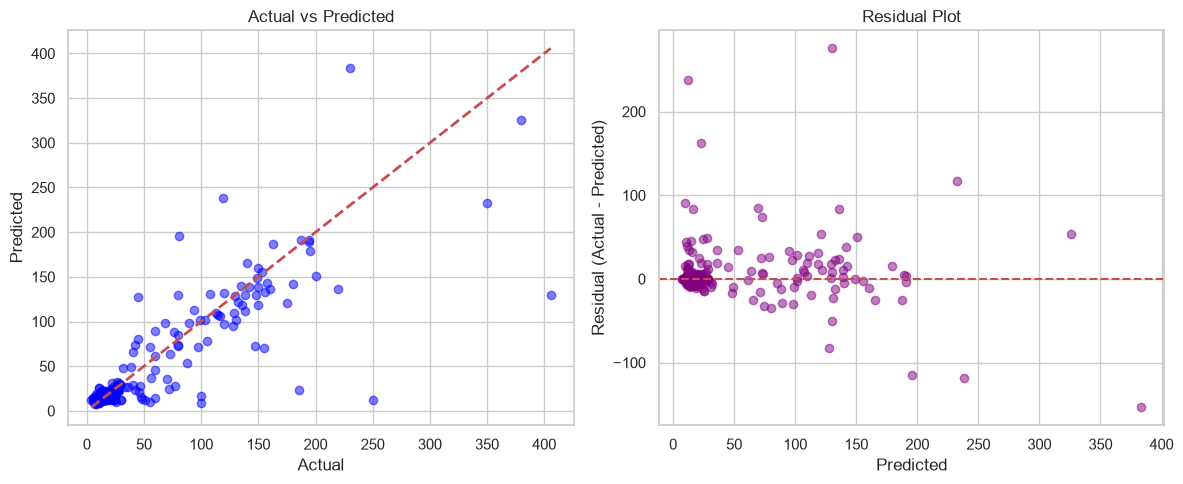

In [42]:
XGBr = change_model(XGBRegressor(random_state=42, objective='reg:absoluteerror', n_jobs = -1), 1)

## D.3 Final Test - w/o Ambigous `price_per_volume` & High Variance

In [43]:
y.describe()

count    1565.000000
mean       53.088754
std        98.529060
min         3.950000
25%        13.000000
50%        18.720000
75%        40.000000
max      1999.000000
Name: price, dtype: float64

Notice we a light novel listing with price of 1099.99, let's check:

In [44]:
df_price_model[df_price_model['price'] > 500]

,item_id,title,title_length,title_word_count,currency,seller_location,is_boxset,is_special_edition,is_first_print,total_bonus_count,has_signature,has_merch,has_paper_extra,boxset_side_story_edition_included,standalone_side_story_edition,price,price_per_volume,volume_number,volume_number_end,volume_count,text_risk_score,text_risk_score_v2,price_risk_score,total_risk_score,is_ambigous_bulk_pricing,risk_category,volume_confidence,volume_tier,volume_tier_encoded,seller_location_grouped,condition_encoded
69,v1|127923441558|0,1st Print 2009 Sword Art Online Vol.1-29 Japan...,79,13,USD,JP,True,False,True,1,False,False,False,False,False,700.00,24.137931,1.0,29.0,29.0,0,0,0,0,False,Low Risk,high,4,4,JP,3
1877,v1|377253686891|0,Classroom of the Elite Complete English Light ...,73,13,USD,US,True,False,False,0,False,False,False,False,False,1099.99,35.483548,1.0,31.0,31.0,0,0,0,0,False,Low Risk,medium,4,4,US,5
1912,v1|386260627287|0,Mushoku Tensei Vol.1-26 ＋ Extra 1-2 ＋ Special ...,80,14,USD,JP,True,True,False,0,False,False,False,False,False,540.78,20.799231,1.0,26.0,26.0,0,0,0,0,False,Low Risk,high,4,4,JP,4
1966,v1|388769692760|0,BGS9.6 Re:ZERO Starting Life in Another World ...,80,13,USD,JP,False,False,False,1,True,False,False,False,False,1999.00,1999.000000,1.0,NaN,1.0,0,0,0,0,False,Low Risk,medium,1,1,JP,4
1967,v1|388779634089|0,BGS9.6 Rascal Does Not Dream of Bunny Girl Sen...,80,15,USD,JP,False,True,False,1,False,False,True,False,False,999.00,999.000000,1.0,NaN,1.0,0,0,0,0,False,Low Risk,medium,1,1,JP,4


We have 2 problem here:
- item_id: v1|377253686891|0, Classroom of the Elite Complete English Light Novel Set Vol 1-31 Year 1-3:

    is priced at 1099.99 despite not having special_edition and no bonus at all, the `price_per_volume` is at 35.48 dollars which is way more expensive than the original `price_per_volume` of $15.99 which is around $511 in total for BRAND NEW Official Publisher.

    *Refering to*: https://sevenseasentertainment.com/series/classroom-of-the-elite-light-novel/ official listing price.

    Perhaps the correct price should be $199.99?? In any case, the row will be considered invalid & be filtered below.

- item_id: v1|388779634089|0, BGS9.6 Rascal Does Not Dream of Bunny Girl Senpai Vol.1 1st Light novel Obi 2014

    This is an overpriced individual light novel: special edition, making this product a significant noise towards our data. 
    BGS 9.6 (Beckett Grading Services): Grading manga/book that is considered to be rare compared to cards.
    We will discard this row.

In [45]:
def throw_high_variance(df_price_model):
    bulk_lot_mask = (df_price_model['price'] >= 999) 
    print(f"Total rows before exclusion: {len(df_price_model)}")
    print(f"Rows with volume > 1000: {bulk_lot_mask.sum()}")

    # Exclude them for this test
    df_price_model = df_price_model[~bulk_lot_mask].copy()

    print(f"Rows after exclusion: {len(df_price_model)}")
    return df_price_model

In [46]:
df_price_model = throw_ambigous_price(df_price_model)
df_price_model = throw_high_variance(df_price_model)
X, y, df_meta, X_train, X_test, y_train, y_test, indices_train, indices_test = split_train_test(df_price_model)

Total rows before exclusion: 1565
Rows matching bulk-lot ambiguous pattern (volume_count >= 5, price_per_volume < 4.4): 0
Rows after exclusion: 1565
Total rows before exclusion: 1565
Rows with volume > 1000: 3
Rows after exclusion: 1562
Train: 1249, Test: 313


In [47]:
lrr = change_model(LinearRegression(), 0)

        Train    Test  Gap (Train-Test)
R2      0.666   0.621             0.045
MAE    19.459  15.685             3.773
RMSE   46.886  37.661             9.226
MAPE    0.369   0.348             0.021
SMAPE  33.735  31.163             2.572

[OK]:	R2 Gap is acceptable(0.045)


In [48]:
rfr = change_model(RandomForestRegressor(random_state=42, n_jobs=-1), 0)

        Train    Test  Gap (Train-Test)
R2      0.912   0.691             0.221
MAE     8.451  13.323            -4.871
RMSE   24.057  33.987            -9.930
MAPE    0.176   0.295            -0.118
SMAPE  16.828  27.853           -11.025

[!WARN]:	 R2 Wide Gap train-test is detected! = 0.221


In [49]:
XGBr = change_model(XGBRegressor(random_state=42, objective='reg:absoluteerror', n_jobs = -1), 0)

        Train    Test  Gap (Train-Test)
R2      0.873   0.714             0.159
MAE     8.567  12.039            -3.471
RMSE   28.947  32.712            -3.765
MAPE    0.185   0.248            -0.063
SMAPE  18.841  25.218            -6.378

[!WARN]:	 R2 Wide Gap train-test is detected! = 0.159


In [50]:
import warnings
warnings.filterwarnings('ignore')
lgbm = change_model(LGBMRegressor(random_state=42, objective='regression_l1', learning_rate=0.05, force_row_wise = True, reg_alpha=0.1, reg_lambda=1, n_jobs=-1), 0)

[LightGBM] [Info] Total Bins 120
[LightGBM] [Info] Number of data points in the train set: 1249, number of used features: 16
[LightGBM] [Info] Start training from score 2.998229
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
        Train    Test  Gap (Train-Test)
R2      0.760   0.708             0.053
MAE    13.848  12.665             1.183
RMSE   39.690  33.063             6.627
MAPE    0.237   0.256            -0.020
SMAPE  23.517  25.813            -2.295

[OK]:	R2 Gap is acceptable(0.053)


We will use LGBM as our Final Regression Model because it has the least fluctuation of 0.053 between train-test and doesn't present traditional overfit gap such as XGBr with gap of 0.159 and RFR with gap of 0.221.

## D.4 Hyperparameter Tuning & Cross Validation

### D.4.1 Grid Search

In [51]:
from sklearn.metrics import make_scorer
from sklearn.model_selection import RepeatedKFold, GridSearchCV

import warnings
warnings.filterwarnings('ignore')

rkf = RepeatedKFold(n_splits=5, n_repeats=3, random_state=42)
param_grid = {
    'regressor__regressor__num_leaves': [7, 15],          # Diturunkan agar tree tidak terlalu dalam
    'regressor__regressor__min_child_samples': [20, 40],   # Dinaikkan agar leaf butuh sampel lebih banyak
    'regressor__regressor__learning_rate': [0.01, 0.03, 0.05],
    'regressor__regressor__reg_alpha': [0.1, 1.0],        # Paksa regularisasi L1
    'regressor__regressor__reg_lambda': [0.1, 1.0],        # Paksa regularisasi L2
    'regressor__regressor__max_depth': [-1, 3, 5],
    'regressor__regressor__importance_type': ['gain', 'split']
}

scorers = {
    'r2': make_scorer(r2_score),
    'mae': make_scorer(mean_absolute_error, greater_is_better=False), # Negatif karena Sklearn mengoptimalkan loss
    'smape': make_scorer(calculate_smape)
}

grid_search = GridSearchCV(
    estimator=lgbm,
    param_grid = param_grid,
    cv = rkf,
    scoring=scorers,
    refit = 'r2',
    n_jobs = -1,
    verbose = 1
)

grid_search.fit(X_train, y_train)
print("Best parameters:", grid_search.best_params_)
print(f"Best CV r2 Score: {grid_search.best_score_:.3f}")


Fitting 15 folds for each of 288 candidates, totalling 4320 fits
[LightGBM] [Info] Total Bins 120
[LightGBM] [Info] Number of data points in the train set: 1249, number of used features: 16
[LightGBM] [Info] Start training from score 2.998229
Best parameters: {'regressor__regressor__importance_type': 'gain', 'regressor__regressor__learning_rate': 0.05, 'regressor__regressor__max_depth': -1, 'regressor__regressor__min_child_samples': 20, 'regressor__regressor__num_leaves': 15, 'regressor__regressor__reg_alpha': 1.0, 'regressor__regressor__reg_lambda': 0.1}
Best CV r2 Score: 0.700


# E. Sanity & Leakage Check for Best-Tuned Model

In [52]:
cv_results = grid_search.cv_results_
best_index = grid_search.best_index_

# Ambil skor per fold untuk kandidat terbaik
fold_scores = [cv_results[f'split{i}_test_r2'][best_index] for i in range(15)]

print(f"Mean R^2   : {np.mean(fold_scores):.3f}")
print(f"Std R^2    : {np.std(fold_scores):.3f}")
print(f"Min R^2    : {np.min(fold_scores):.3f}")
print(f"Max R^2    : {np.max(fold_scores):.3f}")

Mean R^2   : 0.700
Std R^2    : 0.069
Min R^2    : 0.585
Max R^2    : 0.815


In [53]:
print("Train target stats:\n", y_train.describe())
print("\nTest target stats:\n", y_test.describe())

Train target stats:
 count    1249.000000
mean       52.041914
std        81.121100
min         3.950000
25%        12.990000
50%        19.050000
75%        39.990000
max       700.000000
Name: price, dtype: float64

Test target stats:
 count    313.000000
mean      44.682300
std       61.232929
min        5.000000
25%       13.190000
50%       18.490000
75%       39.990000
max      428.030000
Name: price, dtype: float64


In [54]:
overlap = set(df_meta.loc[indices_test, 'item_id']) & set(df_meta.loc[X_train.index, 'item_id'])
print(f"Overlap item_id train-test: {len(overlap)}")

Overlap item_id train-test: 0


In [55]:
best_model = grid_search.best_estimator_
y_pred_test = best_model.predict(X_test)

r2_test = r2_score(y_test, y_pred_test)
mae_test = mean_absolute_error(y_test, y_pred_test)

print(f"Hold-out Test R^2 : {r2_test:.3f}")
print(f"Hold-out Test MAE : ${mae_test:.2f}")

Hold-out Test R^2 : 0.702
Hold-out Test MAE : $13.01


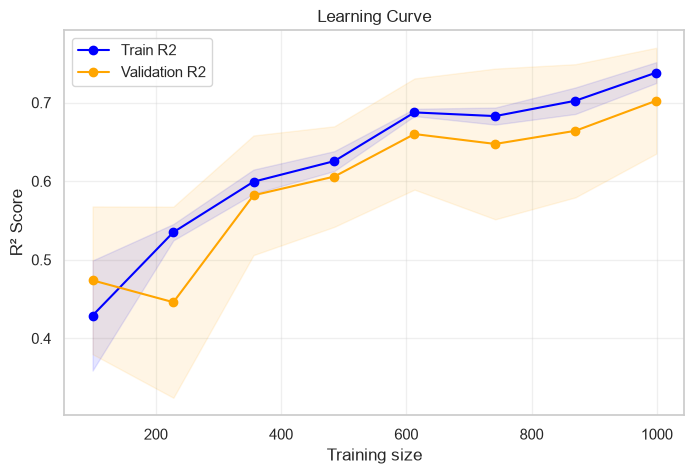

In [56]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(pipeline, X, y, cv=5):
    train_sizes, train_scores, val_scores = learning_curve(
        pipeline, X, y, cv=cv,
        scoring='r2',
        train_sizes=np.linspace(0.1, 1.0, 8),
        n_jobs=-1
    )

    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    val_mean = val_scores.mean(axis=1)
    val_std = val_scores.std(axis=1)

    plt.figure(figsize=(8,5))
    plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Train R2')
    plt.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.1, color='blue')

    plt.plot(train_sizes, val_mean, 'o-', color='orange', label='Validation R2')
    plt.fill_between(train_sizes, val_mean-val_std, val_mean+val_std, alpha=0.1, color='orange')

    plt.xlabel('Training size')
    plt.ylabel('R² Score')
    plt.title('Learning Curve')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

plot_learning_curve(best_model, X_train, y_train)

In [57]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(best_model, X_train, y_train, cv=5, scoring='r2')
print(f"CV R2 scores: {cv_scores.round(3)}")
print(f"Mean: {cv_scores.mean():.3f}, Std: {cv_scores.std():.3f}")

[LightGBM] [Info] Total Bins 118
[LightGBM] [Info] Number of data points in the train set: 999, number of used features: 16
[LightGBM] [Info] Start training from score 2.998229
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Total Bins 116
[LightGBM] [Info] Number of data points in the train set: 999, number of used features: 16
[LightGBM] [Info] Start training from score 2.982140
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Total Bins 115
[LightGBM] [Info] Number of data points in the train set: 999, number of used features: 16
[LightGBM] [Info] Start training from score 2.982140
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Total Bins 118
[LightGBM] [Info] Number of data points in the train set: 999, number of used features: 16
[LightGBM] [Info] Start training from score 3

In [58]:
import numpy as np
import pandas as pd

print("="*60)
print("1. CEK OVERLAP ITEM_ID ANTARA TRAIN DAN TEST")
print("="*60)
train_ids = set(df_meta.loc[X_train.index, 'item_id'])
test_ids = set(df_meta.loc[indices_test, 'item_id'])
overlap = train_ids & test_ids
print(f"Jumlah item train : {len(train_ids)}")
print(f"Jumlah item test  : {len(test_ids)}")
print(f"Overlap item_id   : {len(overlap)}")
if len(overlap) > 0:
    print("⚠️  ADA LEAKAGE! Item yang sama muncul di train dan test.")
    print(list(overlap)[:10])
else:
    print("✅ Tidak ada overlap item_id.")


print("\n" + "="*60)
print("2. DISTRIBUSI TARGET: TRAIN vs TEST")
print("="*60)
comp = pd.DataFrame({
    'Train': y_train.describe(),
    'Test': y_test.describe()
})
print(comp.round(2))

# Cek juga apakah test set kebetulan "lebih sempit/mudah"
print(f"\nCoefficient of Variation (std/mean):")
print(f"  Train: {y_train.std()/y_train.mean():.3f}")
print(f"  Test : {y_test.std()/y_test.mean():.3f}")
print("(CV test jauh lebih kecil dari train -> test lebih 'mudah' diprediksi)")

1. CEK OVERLAP ITEM_ID ANTARA TRAIN DAN TEST
Jumlah item train : 1249
Jumlah item test  : 313
Overlap item_id   : 0
✅ Tidak ada overlap item_id.

2. DISTRIBUSI TARGET: TRAIN vs TEST
         Train    Test
count  1249.00  313.00
mean     52.04   44.68
std      81.12   61.23
min       3.95    5.00
25%      12.99   13.19
50%      19.05   18.49
75%      39.99   39.99
max     700.00  428.03

Coefficient of Variation (std/mean):
  Train: 1.559
  Test : 1.370
(CV test jauh lebih kecil dari train -> test lebih 'mudah' diprediksi)


In [59]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("4. MULTI-SEED HOLD-OUT VALIDATION")
print("="*60)

# Gabungkan X_train+X_test dan y_train+y_test jadi satu dataset utuh
# supaya bisa displit ulang dengan berbagai random_state
X_full = pd.concat([X_train, X_test], axis=0)
y_full = pd.concat([y_train, y_test], axis=0)
idx_full = X_full.index

seeds = [1, 2, 3, 4, 5, 42, 100]
r2_list, mae_list, rmse_list, mape_list, smape_list = [], [], [], [], []

best_params_only = {
    k.replace('regressor__regressor__', ''): v 
    for k, v in grid_search.best_params_.items()
}

price_bins = pd.qcut(y_full, q=4, labels=False, duplicates='drop')

for seed in seeds:
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_full, y_full, test_size=0.2, random_state=seed, stratify=price_bins
    )

    # Clone pipeline terbaik supaya tidak reuse fitted state
    from sklearn.base import clone
    model_clone = clone(grid_search.best_estimator_)
    model_clone.fit(X_tr, y_tr)
    y_pred = model_clone.predict(X_te)

    r2 = r2_score(y_te, y_pred)
    mae = mean_absolute_error(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    mape = mean_absolute_percentage_error(y_te, y_pred)
    smape = calculate_smape(y_te, y_pred)

    r2_list.append(r2)
    mae_list.append(mae)
    rmse_list.append(rmse)
    mape_list.append(mape)
    smape_list.append(smape)
    # print(f"Seed {seed:3d} | R2 = {r2:.3f} | MAE = {mae:.2f}")

def summarize_metric(values, name):
    values = np.array(values)
    return {
        'Metric': name,
        'Mean': values.mean(),
        'Std': values.std(),
        'Min': values.min(),
        'Max': values.max(),
        'Range': values.max() - values.min()
    }

summary_df = pd.DataFrame([
    summarize_metric(r2_list, 'R2'),
    summarize_metric(mae_list, 'MAE'),
    summarize_metric(rmse_list, 'RMSE'),
    summarize_metric(mape_list, 'MAPE'),
    summarize_metric(smape_list, 'SMAPE'),
])

summary_df = summary_df.set_index('Metric').round(3)

if np.std(r2_list) > 0.1:
    print("\n⚠️  Std R2 tinggi antar seed -> performa model TIDAK STABIL,")
    print("   kemungkinan besar karena dataset terlalu kecil, bukan overfit klasik.")
else:
    print("\n✅ Performa model relatif stabil antar split.")

4. MULTI-SEED HOLD-OUT VALIDATION
[LightGBM] [Info] Total Bins 121
[LightGBM] [Info] Number of data points in the train set: 1249, number of used features: 17
[LightGBM] [Info] Start training from score 2.981633
[LightGBM] [Info] Total Bins 122
[LightGBM] [Info] Number of data points in the train set: 1249, number of used features: 17
[LightGBM] [Info] Start training from score 2.981633
[LightGBM] [Info] Total Bins 120
[LightGBM] [Info] Number of data points in the train set: 1249, number of used features: 17
[LightGBM] [Info] Start training from score 2.981633
[LightGBM] [Info] Total Bins 122
[LightGBM] [Info] Number of data points in the train set: 1249, number of used features: 17
[LightGBM] [Info] Start training from score 2.981633
[LightGBM] [Info] Total Bins 121
[LightGBM] [Info] Number of data points in the train set: 1249, number of used features: 17
[LightGBM] [Info] Start training from score 2.981633
[LightGBM] [Info] Total Bins 121
[LightGBM] [Info] Number of data points in 

In [60]:
print(summary_df)

          Mean    Std     Min     Max   Range
Metric                                       
R2       0.751  0.056   0.662   0.833   0.171
MAE     14.320  1.016  13.193  16.385   3.192
RMSE    35.831  4.877  28.777  43.854  15.077
MAPE     0.274  0.019   0.248   0.306   0.058
SMAPE   26.556  1.124  24.383  27.859   3.476


In [61]:
print("="*60)
print("5. PERBANDINGAN DENGAN HASIL ASLI")
print("="*60)
print(f"Hold-out original  : R2 = 0.772  (kemungkinan salah satu titik di distribusi)")
print(f"Multi-seed mean     : R2 = {np.mean(r2_list):.3f}")
print(f"Apakah 0.772 termasuk outlier tinggi? {'YA' if 0.772 >= np.mean(r2_list) + np.std(r2_list) else 'Tidak terlalu ekstrem'}")

5. PERBANDINGAN DENGAN HASIL ASLI
Hold-out original  : R2 = 0.772  (kemungkinan salah satu titik di distribusi)
Multi-seed mean     : R2 = 0.751
Apakah 0.772 termasuk outlier tinggi? Tidak terlalu ekstrem


In [62]:
print(f"R² = {np.mean(r2_list):.3f} ± {np.std(r2_list):.3f}")
print(f"95% range kira-kira: [{np.mean(r2_list) - 1.96*np.std(r2_list):.3f}, "
      f"{np.mean(r2_list) + 1.96*np.std(r2_list):.3f}]")

R² = 0.751 ± 0.056
95% range kira-kira: [0.641, 0.862]


# F. Final Model Inspection

In [63]:
best_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('scale', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](16,)","['title_length','title_word_count','volume_count',...,'has_signature', 'has_merch','has_paper_extra']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,16
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('bool', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically pa

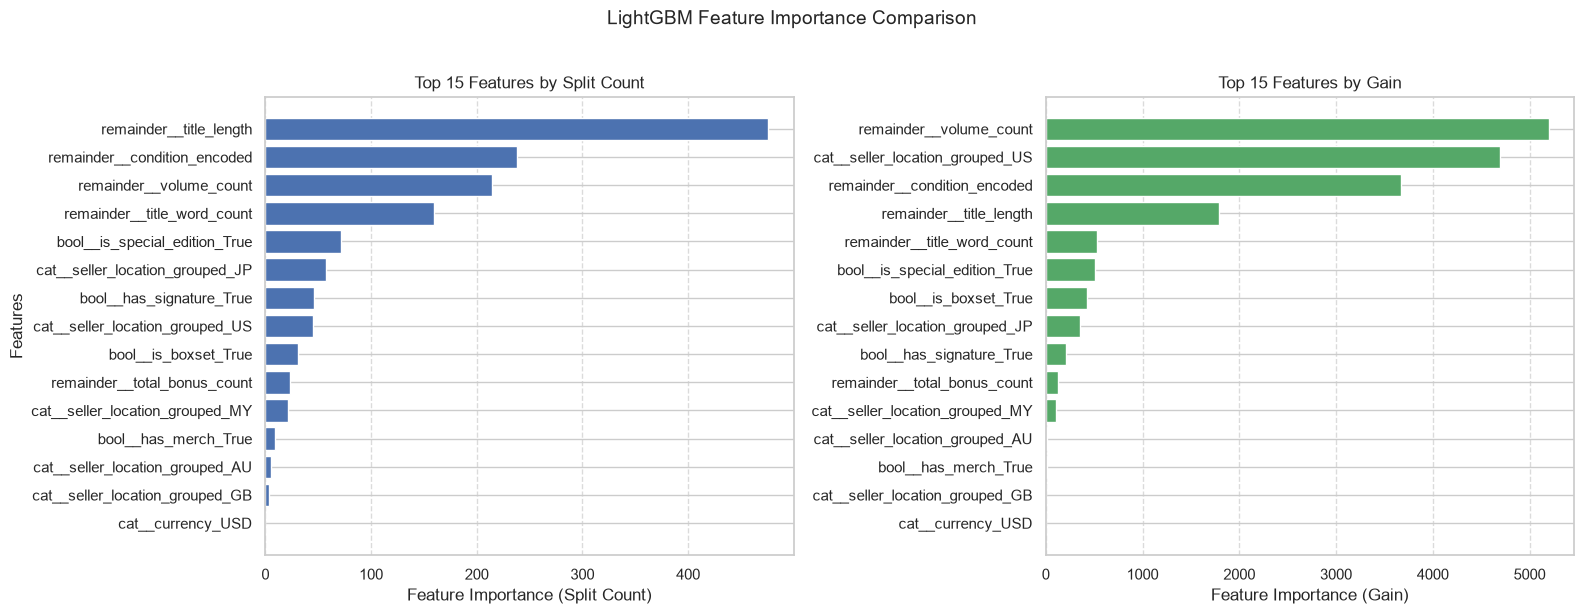

In [64]:
def plot_feature_importance(pipeline, top_n=15):
    # 1. Ekstrak objek ColumnTransformer & LightGBM dari Pipeline
    preprocessor = pipeline.named_steps['preprocessor']
    ttr_model = pipeline.named_steps['regressor'] # TransformedTargetRegressor
    lgbm_model = ttr_model.regressor_             # LGBMRegressor aktual

    # 2. Ambil nama fitur setelah OneHotEncoder & passthrough
    feature_names = preprocessor.get_feature_names_out()

    # 3. Buat DataFrame Feature Importance
    df_imp = pd.DataFrame({
        'feature': feature_names,
        'importance': lgbm_model.booster_.feature_importance(importance_type='split')
    }).sort_values('importance', ascending=False)

    df_gain = pd.DataFrame({
        'feature': feature_names,
        'importance':  lgbm_model.booster_.feature_importance(importance_type='gain')
    }).sort_values('importance', ascending=False)
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Plot 1: Split Count (axes[0])
    axes[0].barh(df_imp['feature'][:top_n][::-1], df_imp['importance'][:top_n][::-1], color='#4C72B0')
    axes[0].set_xlabel('Feature Importance (Split Count)')
    axes[0].set_ylabel('Features')
    axes[0].set_title(f'Top {top_n} Features by Split Count')
    axes[0].grid(axis='x', linestyle='--', alpha=0.7)

    # Plot 2: Gain (axes[1])
    axes[1].barh(df_gain['feature'][:top_n][::-1], df_gain['importance'][:top_n][::-1], color='#55A868')
    axes[1].set_xlabel('Feature Importance (Gain)')
    # Hilangkan ylabel di plot kanan agar tidak menumpuk/redundan
    axes[1].set_title(f'Top {top_n} Features by Gain')
    axes[1].grid(axis='x', linestyle='--', alpha=0.7)

    plt.suptitle('LightGBM Feature Importance Comparison', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

    return df_imp, df_gain, lgbm_model

# Cara panggil setelah running change_model:
df_imp, df_gain, lgbmr = plot_feature_importance(best_model)
